Load and Explore the Dataset


In [3]:
import numpy as np
import pandas as pd
df=pd.read_csv("world_bank_dataset.csv")
df

,Country,Year,GDP (USD),Population,Life Expectancy,Unemployment Rate (%),CO2 Emissions (metric tons per capita),Access to Electricity (%)
0,Brazil,2010,1.493220e+12,8.290200e+08,66.7,3.81,10.79,76.76
1,Japan,2011,1.756270e+13,8.970100e+08,61.4,17.98,15.67,67.86
2,India,2012,1.642688e+13,6.698500e+08,69.1,16.02,2.08,81.08
3,Mexico,2013,1.189001e+13,1.138000e+08,80.1,6.26,19.13,53.46
4,India,2014,2.673020e+12,2.971000e+07,62.7,3.10,15.66,82.17
...,...,...,...,...,...,...,...,...
195,India,2015,1.110880e+12,6.727800e+08,78.5,22.30,11.36,66.04
196,Australia,2016,9.210290e+12,6.896500e+08,64.9,9.82,15.59,67.29
197,United States,2017,4.937150e+12,1.234820e+09,61.0,4.14,14.66,91.16
198,Canada,2018,1.088696e+13,2.625900e+08,76.5,2.28,7.25,59.21


In [5]:
df.size

1600

In [7]:
df.shape

(200, 8)

In [9]:
df.info

<bound method DataFrame.info of             Country  Year     GDP (USD)    Population  Life Expectancy  \
0            Brazil  2010  1.493220e+12  8.290200e+08             66.7   
1             Japan  2011  1.756270e+13  8.970100e+08             61.4   
2             India  2012  1.642688e+13  6.698500e+08             69.1   
3            Mexico  2013  1.189001e+13  1.138000e+08             80.1   
4             India  2014  2.673020e+12  2.971000e+07             62.7   
..              ...   ...           ...           ...              ...   
195           India  2015  1.110880e+12  6.727800e+08             78.5   
196       Australia  2016  9.210290e+12  6.896500e+08             64.9   
197   United States  2017  4.937150e+12  1.234820e+09             61.0   
198          Canada  2018  1.088696e+13  2.625900e+08             76.5   
199  United Kingdom  2019  4.525980e+12  5.354700e+08             73.7   

     Unemployment Rate (%)  CO2 Emissions (metric tons per capita)  \
0        

In [13]:
df.describe

<bound method NDFrame.describe of             Country  Year     GDP (USD)    Population  Life Expectancy  \
0            Brazil  2010  1.493220e+12  8.290200e+08             66.7   
1             Japan  2011  1.756270e+13  8.970100e+08             61.4   
2             India  2012  1.642688e+13  6.698500e+08             69.1   
3            Mexico  2013  1.189001e+13  1.138000e+08             80.1   
4             India  2014  2.673020e+12  2.971000e+07             62.7   
..              ...   ...           ...           ...              ...   
195           India  2015  1.110880e+12  6.727800e+08             78.5   
196       Australia  2016  9.210290e+12  6.896500e+08             64.9   
197   United States  2017  4.937150e+12  1.234820e+09             61.0   
198          Canada  2018  1.088696e+13  2.625900e+08             76.5   
199  United Kingdom  2019  4.525980e+12  5.354700e+08             73.7   

     Unemployment Rate (%)  CO2 Emissions (metric tons per capita)  \
0      

In [15]:
df.dtypes

Country                                    object
Year                                        int64
GDP (USD)                                 float64
Population                                float64
Life Expectancy                           float64
Unemployment Rate (%)                     float64
CO2 Emissions (metric tons per capita)    float64
Access to Electricity (%)                 float64
dtype: object

Handle Missing Data

In [20]:
df.isna().sum()

Country                                   0
Year                                      0
GDP (USD)                                 0
Population                                0
Life Expectancy                           0
Unemployment Rate (%)                     0
CO2 Emissions (metric tons per capita)    0
Access to Electricity (%)                 0
dtype: int64

Visualization

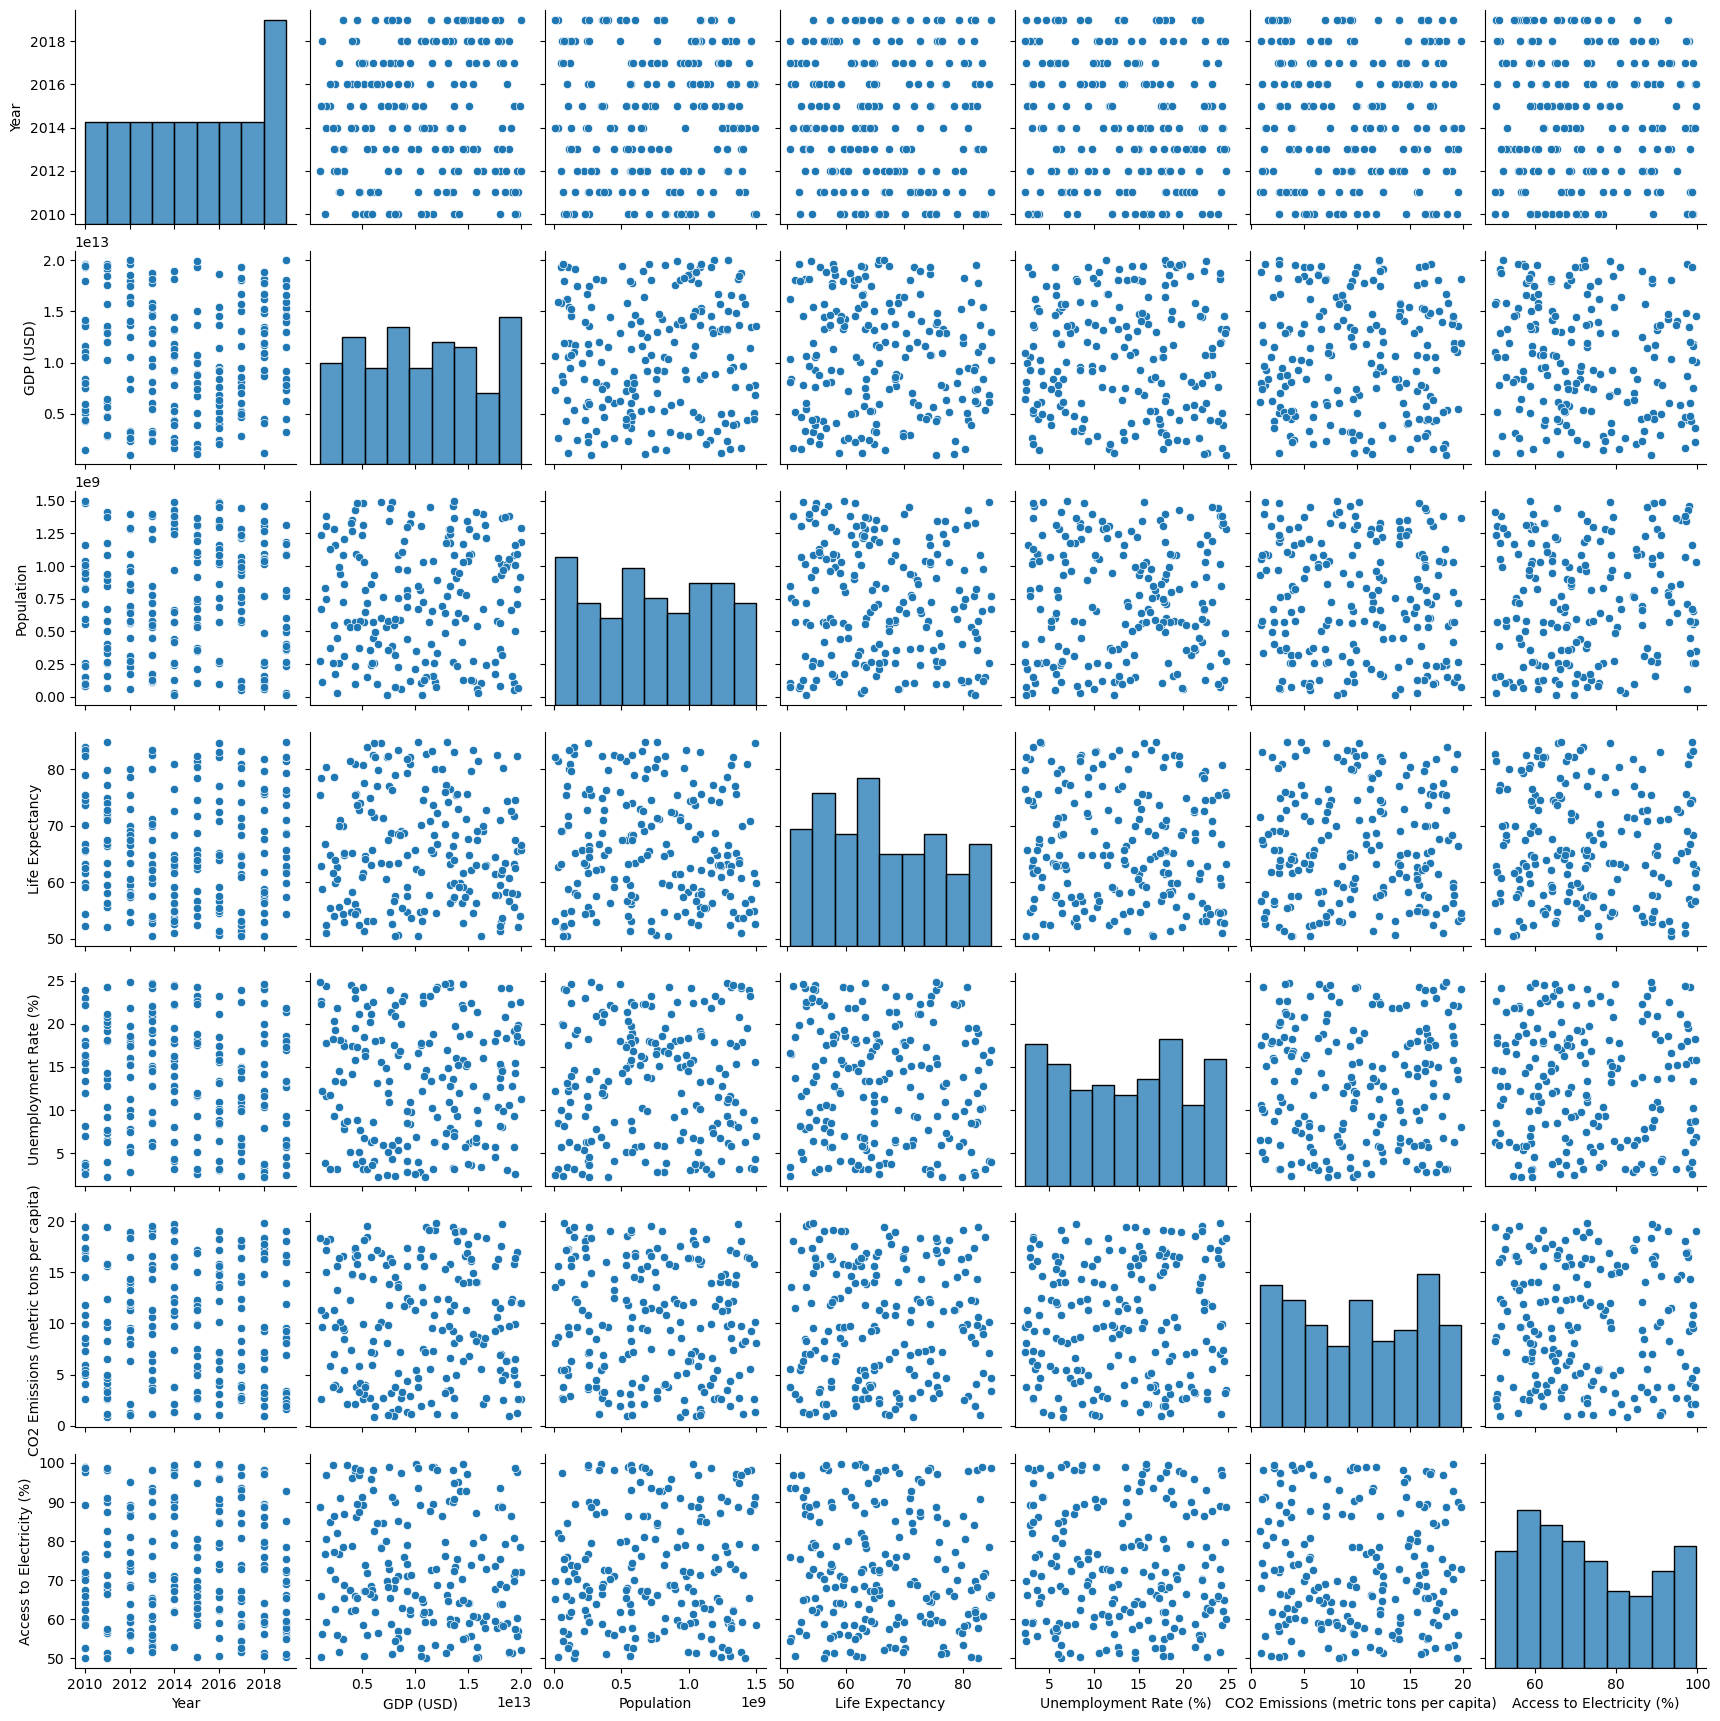

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df)
plt.show()

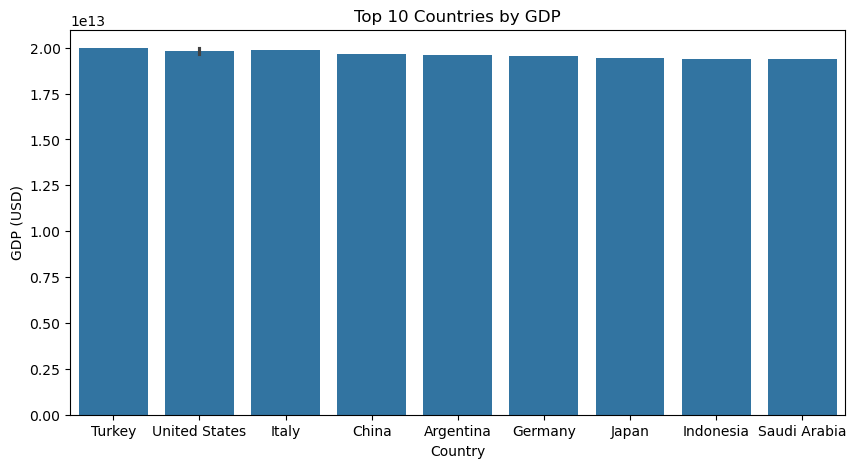

In [40]:
top_gdp=df.sort_values(by="GDP (USD)",ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x='Country',y='GDP (USD)',data=top_gdp)
plt.title("Top 10 Countries by GDP")
plt.show()

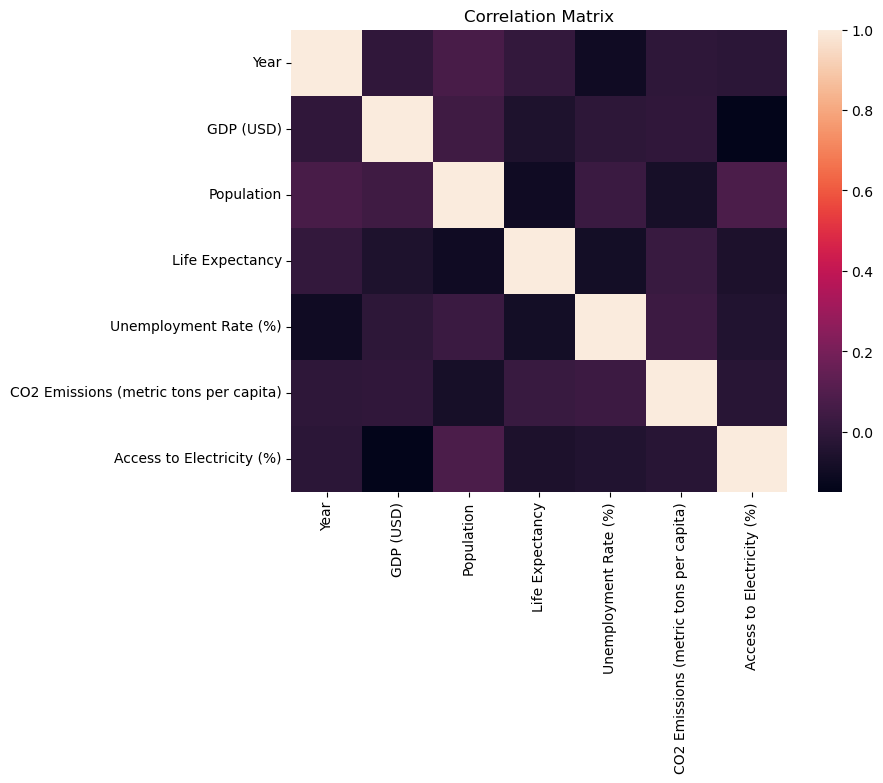

In [48]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True))
plt.title("Correlation Matrix")
plt.show()

Select Numerical Features for Clustering

In [53]:
a=df.drop("Country",axis=1)
a

,Year,GDP (USD),Population,Life Expectancy,Unemployment Rate (%),CO2 Emissions (metric tons per capita),Access to Electricity (%)
0,2010,1.493220e+12,8.290200e+08,66.7,3.81,10.79,76.76
1,2011,1.756270e+13,8.970100e+08,61.4,17.98,15.67,67.86
2,2012,1.642688e+13,6.698500e+08,69.1,16.02,2.08,81.08
3,2013,1.189001e+13,1.138000e+08,80.1,6.26,19.13,53.46
4,2014,2.673020e+12,2.971000e+07,62.7,3.10,15.66,82.17
...,...,...,...,...,...,...,...
195,2015,1.110880e+12,6.727800e+08,78.5,22.30,11.36,66.04
196,2016,9.210290e+12,6.896500e+08,64.9,9.82,15.59,67.29
197,2017,4.937150e+12,1.234820e+09,61.0,4.14,14.66,91.16
198,2018,1.088696e+13,2.625900e+08,76.5,2.28,7.25,59.21


Feature Scaling (Important for K-Means)

Use Elbow Method to Choose k

In [57]:
from sklearn.cluster import KMeans

c=[]
for i in range(1,11):
    d=KMeans(n_clusters=i,init='k-means++',random_state=42)
    d.fit(a)
    c.append(d.inertia_)
print(c) 

C:\Users\trees\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
invalid literal for int() with base 10: ''
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\trees\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 268, in _count_physical_cores
    cpu_count_physical = sum(map(int, cpu_info))
                         ^^^^^^^^^^^^^^^^^^^^^^^
C:\Users\trees\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\trees\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to

[6.124625236895263e+27, 1.5170236807327202e+27, 7.346772761384095e+26, 3.634385220914869e+26, 2.4882403034913316e+26, 1.5512580055134045e+26, 1.33562271340211e+26, 8.528769231057697e+25, 7.50637364787513e+25, 6.100792043801503e+25]


C:\Users\trees\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


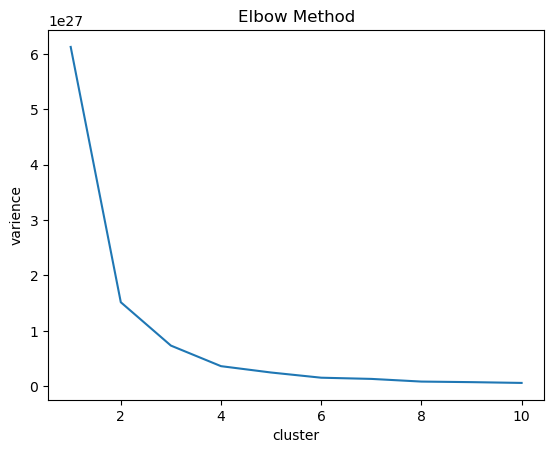

In [59]:
import matplotlib.pyplot as plt
plt.plot(range(1,11),c)
plt.xlabel('cluster')
plt.ylabel("varience")
plt.title("Elbow Method")
plt.show()

Apply KMeans Clustering

In [65]:
e=KMeans(n_clusters=3,init='k-means++',random_state=42)
output=e.fit_predict(a)
output

C:\Users\trees\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 1, 1, 2, 0, 2, 0, 2, 2, 2, 2, 1, 2, 0, 0, 2, 0, 1, 2, 2, 2, 0,
       2, 1, 2, 0, 0, 1, 1, 0, 1, 2, 0, 0, 0, 1, 2, 2, 0, 2, 2, 0, 1, 0,
       2, 0, 1, 2, 1, 1, 0, 2, 1, 0, 2, 0, 2, 1, 2, 1, 0, 0, 0, 1, 0, 2,
       1, 0, 0, 1, 0, 2, 1, 0, 0, 2, 0, 1, 1, 1, 0, 1, 0, 2, 2, 1, 0, 1,
       1, 0, 2, 0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 0, 2, 1, 0, 1, 0, 0, 2, 2,
       2, 2, 2, 0, 2, 0, 0, 0, 2, 2, 1, 2, 1, 0, 2, 0, 0, 1, 1, 1, 1, 0,
       2, 1, 2, 0, 0, 0, 2, 1, 2, 1, 0, 1, 2, 2, 2, 0, 1, 2, 2, 1, 1, 2,
       0, 0, 2, 0, 1, 0, 1, 1, 1, 2, 0, 2, 0, 0, 2, 0, 0, 2, 2, 0, 2, 2,
       2, 2, 0, 0, 0, 1, 0, 1, 1, 0, 2, 1, 2, 2, 0, 0, 0, 2, 0, 0, 2, 0,
       2, 0])

In [80]:
df['cluster']=output
df

,Country,Year,GDP (USD),Population,Life Expectancy,Unemployment Rate (%),CO2 Emissions (metric tons per capita),Access to Electricity (%),cluster
0,Brazil,2010,1.493220e+12,8.290200e+08,66.7,3.81,10.79,76.76,0
1,Japan,2011,1.756270e+13,8.970100e+08,61.4,17.98,15.67,67.86,1
2,India,2012,1.642688e+13,6.698500e+08,69.1,16.02,2.08,81.08,1
3,Mexico,2013,1.189001e+13,1.138000e+08,80.1,6.26,19.13,53.46,2
4,India,2014,2.673020e+12,2.971000e+07,62.7,3.10,15.66,82.17,0
...,...,...,...,...,...,...,...,...,...
195,India,2015,1.110880e+12,6.727800e+08,78.5,22.30,11.36,66.04,0
196,Australia,2016,9.210290e+12,6.896500e+08,64.9,9.82,15.59,67.29,2
197,United States,2017,4.937150e+12,1.234820e+09,61.0,4.14,14.66,91.16,0
198,Canada,2018,1.088696e+13,2.625900e+08,76.5,2.28,7.25,59.21,2


Visualize Cluster Results

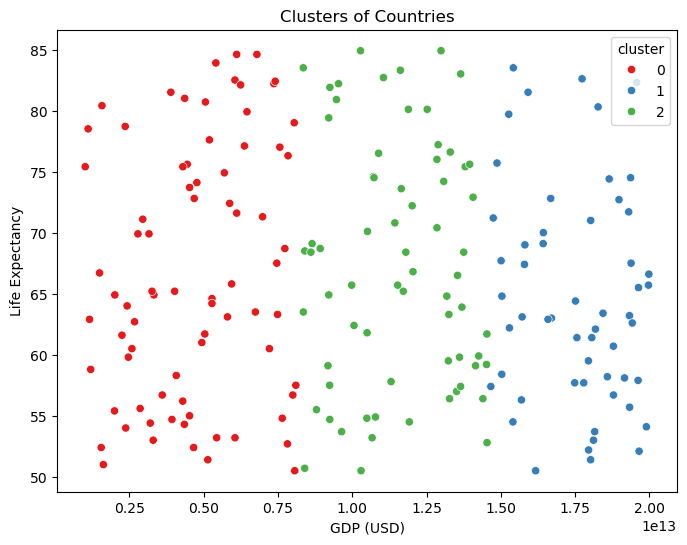

In [82]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['GDP (USD)'],
    y=df['Life Expectancy'],
    hue=df['cluster'],
    palette='Set1'
)
plt.title("Clusters of Countries")
plt.show()

In [94]:
cluster_summary = df.groupby('cluster')['Life Expectancy'].mean()
print(cluster_summary)

cluster
0    66.657143
1    64.594545
2    67.347059
Name: Life Expectancy, dtype: float64


In [100]:
cluster_summary1 = df.groupby('cluster')['Unemployment Rate (%)'].mean()
print(cluster_summary1)

cluster
0    13.522468
1    12.980364
2    13.223235
Name: Unemployment Rate (%), dtype: float64


In [104]:
cluster_summary2 = df.groupby('cluster')['GDP (USD)'].mean()
print(cluster_summary2)

cluster
0    4.712409e+12
1    1.755393e+13
2    1.155020e+13
Name: GDP (USD), dtype: float64


In [106]:
cluster_summary2 = df.groupby('cluster')['CO2 Emissions (metric tons per capita)'].mean()
print(cluster_summary2)

cluster
0     9.887403
1    10.202727
2    10.134706
Name: CO2 Emissions (metric tons per capita), dtype: float64


In [108]:
cluster_summary2 = df.groupby('cluster')['Access to Electricity (%)'].mean()
print(cluster_summary2)

cluster
0    75.507403
1    68.908545
2    73.107500
Name: Access to Electricity (%), dtype: float64


In [112]:
cluster_summary0 = df.groupby('cluster').mean(numeric_only=True)
print(cluster_summary0)

                Year     GDP (USD)    Population  Life Expectancy  \
cluster                                                             
0        2014.363636  4.712409e+12  7.165664e+08        66.657143   
1        2014.581818  1.755393e+13  7.617909e+08        64.594545   
2        2014.588235  1.155020e+13  7.453538e+08        67.347059   

         Unemployment Rate (%)  CO2 Emissions (metric tons per capita)  \
cluster                                                                  
0                    13.522468                                9.887403   
1                    12.980364                               10.202727   
2                    13.223235                               10.134706   

         Access to Electricity (%)  
cluster                             
0                        75.507403  
1                        68.908545  
2                        73.107500  


1. Which cluster has high GDP & high life expectancy?

Which cluster has low electricity & high unemployment?

What policies might help countries in weakest  Cluster ?

In [ ]:
Cluster 1 has high GDP but low electricity
cluster0 has low GDP and high unemployment
so weakest cluster is cluster 0
Suggestion:
  Improve job creation programs
  Improve access to electricity
